# ETFs - Strategy Analysis

This notebook reads the ETF case study's whole registered pipeline - every backtest from the
signal sweep through the risk overlay - and turns it into one strategy assessment. Every metric
carries a block-bootstrap confidence interval, every comparison between two strategies goes
through a paired bootstrap rather than a difference of point estimates, and the holdout closure
is read the same way. Comparison across case studies is Chapter 20's subject.

**Learning objectives**

- Read uncertainty-aware backtest metrics - Sharpe with its interval, PSR, DSR - from the
  registry rather than transcribing point estimates.
- Trace one strategy configuration through the four pipeline stages
  (signal to allocation → cost → risk) with paired-bootstrap stage
  transitions.
- Use the equal-weight ETF universe benchmark, sliced into validation and holdout periods, for
  both the equity-curve overlay and the holdout strategy-versus-benchmark paired test.
- Layer 1 + Layer 2 benchmark-aware diagnostics: PortfolioAnalysis
  alpha/beta/IR against the equal-weight universe, plus an FF5+MOM
  factor attribution with placebo-portfolio control. The cross-asset
  ETF universe (equities / bonds / commodities / currencies) means
  factor R² is structurally limited; the placebo benchmark separates
  universe-driven from selection-driven factor exposure.

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through `19_holdout_backtest`;
the locked registry (`case_studies/etfs/run_log/registry.db`).

**Scope**: no training and no re-backtesting. It does write two derived tables,
`cohort_metrics` and `backtest_paired_metrics`, and that is a deliberate change from the
read-only scope this notebook used to declare.

Both tables are derived from backtests that already exist - selection-bias statistics over the
cohorts, and paired-bootstrap comparisons between registered return series. Nothing is refitted
and no backtest is added. They were previously produced by a chapter-20 notebook looping over
every case study, which made a case study's own strategy analysis unreadable until a later
chapter had been run, and left both tables empty for any reader working the case study in order.
A stage that cannot be read without running a chapter that comes after it is not a stage. So the
notebook that has every stage in front of it produces them, and re-running it recomputes only
what is missing.

In [1]:
"""ETFs - Strategy Analysis."""

import json
import sqlite3
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml

warnings.filterwarnings("ignore")

from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)

from case_studies.research import open_study, split_unpublished_members
from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.factor_attribution import (
    compute_bootstrap_ci,
    compute_rolling_exposures,
    format_attribution_summary,
    load_factor_data,
    plot_attribution_waterfall,
    plot_rolling_exposures,
    run_factor_regression,
    run_placebo_benchmark,
)
from case_studies.utils.paired_metrics import populate_paired_metrics
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
    load_prediction_index,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    compute_operating_profile,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    gate_passes,
    plot_concentration_curve,
    plot_equity_drawdown,
    plot_sharpe_waterfall,
    resolve_canonical_rank1_lineage,
    resolve_holdout_self_backtest,
    write_strategy_assessment,
)
from case_studies.utils.uncertainty import STAGE_SEQUENCE, descends_from
from utils.paths import get_case_study_dir, get_output_dir

In [2]:
MAX_SYMBOLS = 0
# Both names stay bound here although nothing below reads them: that is what makes the harness
# force preview and supply a workspace (`tests/pm_helpers.py:954`). Without them the canonical
# branch regenerates in place, which needs symlinks a CI checkout does not have.
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""

The study is opened before any path or registry read. Under the preview tier, opening it
activates a workspace and rewrites `ML4T_OUTPUT_DIR` process-wide; a `CASE_DIR` or a
`BacktestExplorer` built first would address the released registry while everything after it
reads the preview one.

In [3]:
CASE_STUDY = "etfs"
PRIMARY_LABEL = "fwd_ret_21d"
PERIODS_PER_YEAR = 252  # NYSE calendar, daily bars
study = open_study(CASE_STUDY, execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
CASE_DIR = get_case_study_dir(CASE_STUDY)
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)

BacktestExplorer('etfs', 3313 runs: allocation=678, cost_sensitivity=85, holdout=1, risk_overlay=80, signal=2469)


**Which prediction sets their publishers still stand behind.** A refit publishes a second
generation under the same population name, and the generation it replaced stays in the registry:
complete, current under a schema version that has not moved, and carrying every backtest the
previous sweep registered for it. The configuration this notebook describes is chosen by
backtest Sharpe over that pool, so without the lineage the analysis can be about a strategy the
case study no longer publishes.

In [4]:
LIVE_PREDICTIONS = (
    split_unpublished_members(
        study,
        load_prediction_index(CASE_STUDY, split="validation"),
    )
    .live["prediction_hash"]
    .to_list()
)
if not LIVE_PREDICTIONS:
    raise RuntimeError(
        f"no live prediction sets for {CASE_STUDY}/validation; run the model stage and "
        "14_backtest first"
    )
print(f"Live prediction sets: {len(LIVE_PREDICTIONS):,}")

# Both derived tables fill in two waves - stage transitions once allocation, cost and risk have
# run, holdout kinds only once the holdout has been evaluated - so the predicate is whether every
# kind this notebook reads is present, not whether anything is.
PAIRED_KINDS = (
    "signal_leader",
    "allocation_leader",
    "cost_sensitivity_leader",
    "val_rank1_self",
    "equal_weight_holdout_side_artifact",
)
COHORT_TYPES = ("family", "stagelabel", "label")


def _derived_table_state() -> tuple[set[str], set[str]]:
    """Which paired kinds and cohort granularities the registry already holds."""
    with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as db:
        tables = {r[0] for r in db.execute("SELECT name FROM sqlite_master WHERE type='table'")}
        kinds = (
            {
                r[0]
                for r in db.execute("SELECT DISTINCT benchmark_kind FROM backtest_paired_metrics")
            }
            if "backtest_paired_metrics" in tables
            else set()
        )
        cohorts = (
            {r[0] for r in db.execute("SELECT DISTINCT cohort_type FROM cohort_metrics")}
            if "cohort_metrics" in tables
            else set()
        )
    return kinds, cohorts


def _stale_derived_rows(live: list[str]) -> tuple[int, int]:
    """Derived rows built over anything this notebook does not report as live.

    Presence of every enum value says the tables were built; it does not say they were built
    over the population this notebook reports. A refit retires the generation a previous run
    led with, and its cohort and paired rows survive intact under those same enum values.

    A leader and a challenger are the visible halves. A cohort is also stale when a retired
    prediction is one of the variants the correction was computed over - the leader can be
    live while the trial count and the deflated Sharpe are not - and a pair is also stale
    when its benchmark side is retired, which is the side the difference is measured
    against. `member_digest` records the cohort's members, so a cohort whose digest is
    absent cannot be shown to be live either and is recomputed rather than trusted.

    Cohort membership is not queryable here - `backtest_runs` carries neither label nor
    family - so the membership test is that the cohort's stage still holds a retired
    backtest at all. `compute_and_register` refreshes the whole table rather than one row,
    so triggering it too readily costs a recompute and can never report a stale number.
    """
    with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as db:
        tables = {r[0] for r in db.execute("SELECT name FROM sqlite_master WHERE type='table'")}
        payload = json.dumps(live)
        stale_cohort = (
            db.execute(
                """
                SELECT COUNT(*) FROM cohort_metrics cm
                WHERE cm.member_digest IS NULL
                   OR cm.leader_hash IN (
                          SELECT backtest_hash FROM backtest_runs
                          WHERE prediction_hash NOT IN (SELECT value FROM json_each(?1))
                      )
                   OR EXISTS (
                          SELECT 1 FROM backtest_runs r
                          WHERE r.stage IS cm.stage
                            AND r.prediction_hash NOT IN (SELECT value FROM json_each(?1))
                      )
                """,
                (payload,),
            ).fetchone()[0]
            if "cohort_metrics" in tables
            else 0
        )
        stale_paired = (
            db.execute(
                """
                SELECT COUNT(*) FROM backtest_paired_metrics pm
                WHERE pm.challenger_hash IN (
                          SELECT backtest_hash FROM backtest_runs
                          WHERE prediction_hash NOT IN (SELECT value FROM json_each(?1))
                      )
                   OR pm.benchmark_hash IN (
                          SELECT backtest_hash FROM backtest_runs
                          WHERE prediction_hash NOT IN (SELECT value FROM json_each(?1))
                      )
                """,
                (payload,),
            ).fetchone()[0]
            if "backtest_paired_metrics" in tables
            else 0
        )
    return stale_cohort, stale_paired


# §1 reports the configuration the validation stages ranked first, and the paired-metrics
# producer below has to be told what it is. Left to itself the producer ranks the registry on
# raw Sharpe, which is a second selector beside this one - it applies neither the common-support
# re-ranking a conformal candidate forces nor the restrictions the resolver holds. The two agree
# on this registry today, which is why the published rows are right; etfs now has a second fully
# backtested label, so agreement is a fact about this registry rather than a property of either
# ranking. So the selection is resolved here, before anything is written, and the two rankings
# are required to agree rather than assumed to.

Live prediction sets: 534


In [5]:
_HOLDOUT_STAGES = ("signal", "allocation", "risk_overlay")
_FIELD = (
    pl.concat(
        [
            explorer.best(stage=s, top_n=2000, prediction_hashes=LIVE_PREDICTIONS)
            for s in _HOLDOUT_STAGES
        ],
        how="diagonal_relaxed",
    )
    .filter(pl.col("family") != "benchmark")
    .sort("sharpe", descending=True)
    .unique(subset=["prediction_hash"], keep="first", maintain_order=True)
)
ADMITTED = frozenset(_FIELD["backtest_hash"].to_list())
top_signal = _FIELD.head(1)
TOP_HASH = top_signal.row(0, named=True)["backtest_hash"]
TOP_PHASH = top_signal.row(0, named=True)["prediction_hash"]
RANK1_FAMILY = top_signal.row(0, named=True)["family"]
RANK1_CONFIG = top_signal.row(0, named=True)["config_name"]
# Every label the case study declares is backtested equal-weight and competes here; what wins
# decides the label everything below is keyed to. Reading `labels.primary` instead was only ever
# right by coincidence, and etfs has a second fully backtested label, so the coincidence is not
# one to rely on. The primary is kept as the declared value, to say when the two differ.
SELECTED_LABEL = top_signal.row(0, named=True)["label"]

# The resolver is given the same field, not the whole registry: it re-ranks on common timestamp
# support wherever a conformal candidate is present, so a row this notebook never admitted would
# otherwise decide how far the intersection reaches and therefore which admitted row wins.
CARRIER = resolve_canonical_rank1_lineage(CASE_STUDY, admitted=ADMITTED)
if CARRIER["val_backtest_hash"] != TOP_HASH:
    raise RuntimeError(
        "this notebook's ranking and the canonical resolver disagree on the carrier: "
        f"{TOP_HASH} against {CARRIER['val_backtest_hash']}. Everything below reports the "
        "first and the paired rows would be written against the second, so the decay would "
        "compare the right holdout against a different strategy."
    )

In [6]:
have_kinds, have_cohorts = _derived_table_state()
stale_cohort, stale_paired = _stale_derived_rows(LIVE_PREDICTIONS)
missing_kinds = sorted(set(PAIRED_KINDS) - have_kinds)
missing_cohorts = sorted(set(COHORT_TYPES) - have_cohorts)
if missing_cohorts or stale_cohort:
    reason = (
        f"{len(missing_cohorts)} granularity(ies) missing"
        if missing_cohorts
        else f"{stale_cohort} row(s) led by a retired prediction"
    )
    counts = compute_and_register(CASE_STUDY, prediction_hashes=LIVE_PREDICTIONS)
    print(
        f"cohort_metrics: recomputed {sum(counts.values())} rows across {sorted(counts)} ({reason})"
    )
else:
    print(
        f"cohort_metrics: {len(have_cohorts)} granularities present and every leader is live, "
        "nothing recomputed"
    )
if missing_kinds or stale_paired:
    reason = (
        f"missing {', '.join(missing_kinds)}"
        if missing_kinds
        else f"{stale_paired} pair(s) challenged by a retired prediction"
    )
    rows = populate_paired_metrics(CASE_STUDY, prediction_hashes=LIVE_PREDICTIONS, carrier=CARRIER)
    written = sum(1 for r in rows if "skip" not in r)
    print(f"backtest_paired_metrics: wrote {written} pairs ({reason})")
else:
    print(
        "backtest_paired_metrics: every kind this notebook reads is present and every "
        "challenger is live, nothing recomputed"
    )

# Both producers are additive: they write the rows this run's population produces and leave
# every other row where it is. So the rebuild above cannot remove a cohort or a pair built over
# a generation that has since been retired, and re-checking only which *kinds* are present would
# report a table that still holds them as clean. The staleness check is run again and its
# residual stated.
#
# Neither producer is asked to prune. `_prune_paired_metrics` deletes the complement of what a
# run wrote, and a run scoped to one label's live predictions has not written the pairs Chapter
# 20 registered for the other labels - pruning to that partial set would delete them. The rows
# are inert for this notebook either way: every reader below resolves a pair by an explicit
# challenger hash taken from the live lineage, never by scanning the table, so a stale row has
# nothing here that would read it. It is stated rather than ignored because that is a property
# of this notebook's readers and not of the table.
residual_cohort, residual_paired = _stale_derived_rows(LIVE_PREDICTIONS)
if residual_cohort or residual_paired:
    print(
        f"derived tables still hold {residual_cohort} cohort row(s) and {residual_paired} "
        "pair(s) from retired generations; no reader below resolves either"
    )
else:
    print("derived tables hold no rows from retired generations")

have_kinds, have_cohorts = _derived_table_state()
STILL_MISSING_KINDS = sorted(set(PAIRED_KINDS) - have_kinds)
if STILL_MISSING_KINDS:
    # Named rather than left to surface as an empty frame eight cells later. The holdout kinds
    # are absent until the holdout has been evaluated, which is a stage that has not run rather
    # than a failure of this one.
    print(f"  still unavailable: {', '.join(STILL_MISSING_KINDS)}")


def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    """Compact `point [lo, hi]` formatter with NULL-safety."""
    if point is None:
        return "-"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [-, -]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"


def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "-" if val is None else format(val, fmt)


# The stage transitions below are read off `champion_lineage`, which takes the highest-Sharpe
# backtest at each stage independently. Two consecutive entries therefore share a prediction and
# nothing else: `populate_paired_metrics` says so where it builds them - "the pair is a stage
# comparison, not a demonstrated parent and child". Nothing in `backtest_paired_metrics` records
# which axes moved, so a difference produced by three simultaneous changes and one produced by a
# single change are stored identically and read alike.
#
# The cost stage makes that concrete rather than theoretical. `cost_sensitivity` is a monotone
# grid - the same strategy priced at seventeen cost levels - so its Sharpe maximum is the
# zero-cost point by construction, in this case study and in every other. Taking it as "the cost
# stage's leader" makes the allocation-to-cost transition a comparison of the same returns with
# friction switched off, and reports the saving as a gain the cost model contributed. Its interval
# is tight and its p-value is zero because the two series are nearly identical, which is a
# property of the comparison rather than evidence for it.
#
# So each transition prints the axes that actually differ, and the reading is qualified when more
# than one of them moved.
_COST_KEYS = ("commission", "slippage")


def _axes(backtest_hash: str) -> dict:
    """The comparable axes of one registered backtest, read from its stored specification."""
    with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as db:
        row = db.execute(
            "SELECT spec_json FROM backtest_runs WHERE backtest_hash = ?", (backtest_hash,)
        ).fetchone()
    if row is None or not row[0]:
        return {}
    spec = json.loads(row[0])
    config = spec.get("backtest_config", {})
    strategy = spec.get("strategy", {})
    axes = {
        "allocator": strategy.get("allocation", {}).get("method"),
        "concentration": strategy.get("signal", {}).get("top_k"),
        "risk overlay": (strategy.get("risk") or {}).get("name"),
    }
    for key in _COST_KEYS:
        axes[key] = json.dumps(config.get(key, {}), sort_keys=True)
    return axes


def _priced(axes: dict) -> bool:
    """Whether this backtest charges anything at all to trade."""
    for key in _COST_KEYS:
        model = json.loads(axes.get(key) or "{}")
        if any(type(v) in (int, float) and v > 0 for v in model.values()):
            return True
    return False


def _changed(challenger_hash: str, benchmark_hash: str) -> list[str]:
    """Which axes differ between a transition's two sides, in reading order."""
    chal, bench = _axes(challenger_hash), _axes(benchmark_hash)
    if not chal or not bench:
        return []
    moved = [name for name in chal if chal[name] != bench[name]]
    # The two cost keys always move together here and name one decision, so they read as one.
    if set(_COST_KEYS) <= set(moved):
        moved = [m for m in moved if m not in _COST_KEYS] + ["cost model"]
    return moved

[cohort_metrics] etfs (ppy=252)


  family: 27 cohorts


    [1/27] family stage=signal label=fwd_ret_21d family=linear leader=4456db56 K=78 K_eff_mp=3.0 K_eff_er=1.6975744551277836 dsr_er=0.031899779494152784 (0.2s)


    [2/27] family stage=signal label=fwd_ret_5d family=linear leader=ea6c568e K=156 K_eff_mp=4.0 K_eff_er=1.9388385413939386 dsr_er=0.03725747064142916 (0.3s)


    [3/27] family stage=allocation label=fwd_ret_5d family=linear leader=0bbf342b K=36 K_eff_mp=2.0 K_eff_er=1.8327111870545678 dsr_er=0.04102787984274224 (1.2s)


...

    + equal_weight_holdout_side_artifact: sharpe_diff=-0.23999743906769377


    + val_rank1_self: sharpe_diff=-0.13540059392035841


    + allocation_leader: sharpe_diff=0.3786550023414247


    + risk_overlay_leader: sharpe_diff=0.2782629525701945


backtest_paired_metrics: wrote 5 pairs (missing equal_weight_holdout_side_artifact, val_rank1_self)
derived tables still hold 23 cohort row(s) and 2 pair(s) from retired generations; no reader below resolves either


## §1 What the strategy phase inherits

The strategy phase does not choose a model. It receives one: **the configuration with the
highest validation backtest Sharpe** across the holdout-eligible stages, where a configuration
is the whole package - model, label, feature set, backtest settings and any risk overlay - and
the checkpoint is part of it. Everything below describes that one configuration rather than
comparing candidates. Note which metric selected it: not the information coefficient, which
orders nothing here, and not a chapter's headline figure. [`13_model_analysis`](13_model_analysis.ipynb)
is where the population was described; the choosing happened in the backtest stages.

The prediction-side information coefficient printed below is the upstream prior on everything
that follows. If the ranking the strategy trades on is not credibly different from zero, a
strategy Sharpe that looks good is a fact about the portfolio construction and the window rather
than about the signal - and the interval on the IC is what says which case this is.

In [7]:
_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()
ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={SELECTED_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print()
print("Daily-pooled IC (validation):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3f}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=gbm, config=leaves_63_mse, label=fwd_ret_5d
        prediction_hash=be66662dd642, backtest_hash=303a3d07b83e

Daily-pooled IC (validation):
  IC = 0.0106 [-0.0130, 0.0342]  (HAC, lag=7)
  t_HAC = 0.878, p_HAC = 0.380
  n_days = 2011, pct_positive = 50.4%
  CI status: straddles_zero


**Read the interval, not the point.** A daily-pooled IC is an average of many daily rank
correlations on an overlapping label, so consecutive days are dependent and the HAC correction is
what makes its interval mean anything. Whether that interval clears zero is the question; the
magnitude is small on this panel either way, because the instruments are themselves diversified
and there is little idiosyncratic variation left to rank.

**What follows from each answer.** An interval clearing zero sets the expectation that the
strategy Sharpe in §3 should also be credible, and makes it worth asking what went wrong if it is
not. An interval spanning zero says the opposite: whatever §3 reports has no upstream support,
and a good Sharpe there needs explaining rather than celebrating.

**Kill conditions are not declared in `setup.yaml`.** §9 evaluates two universal gates: the
validation Sharpe interval's lower bound against zero, and the holdout strategy-versus-equal-
weight paired interval against zero on the negative side. Both are reported as pass, partial or
fail, and neither is a judgement on the strategy.

## §2 Where the leader sits in the search that produced it

A leader is the maximum of a search, and the maximum of a search is not the same quantity as the
performance of a strategy chosen in advance. The table below puts it back in context: how many
backtests the signal stage produced, where their Sharpe ratios fell, and how far above the middle
of that distribution the leader sits.

The wider that distribution and the more configurations in it, the more of the leader's margin is
attributable to having looked. §9's selection-adjusted statistics price that directly; this
section is where the shape it prices becomes visible.

In [8]:
ctx = explorer.search_context("signal", prediction_hashes=LIVE_PREDICTIONS)
search_table = pl.DataFrame(
    [
        {"metric": "Total signal backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Signal-stage search context:")
print(search_table)

Signal-stage search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total signal backtests      ┆ 2,289  │
│ Mean Sharpe                 ┆ 0.429  │
│ Median Sharpe               ┆ 0.447  │
│ P90 Sharpe                  ┆ 0.597  │
│ % positive Sharpe           ┆ 99.5%  │
│ Top-by-Sharpe in this sweep ┆ 0.930  │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


In [9]:
with sqlite3.connect(str(_db)) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t  ON p.training_hash = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
              AND b.prediction_hash IN (SELECT value FROM json_each(?))
            """,
            (json.dumps(LIVE_PREDICTIONS),),
        ).fetchall(),
        schema=["family", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )

family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level signal-stage Sharpe summary:")
print(family_summary)

Family-level signal-stage Sharpe summary:
shape: (5, 7)
┌────────────────┬──────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n    ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---            ┆ ---  ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32  ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪══════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ latent_factors ┆ 153  ┆ 0.519548      ┆ 0.448053   ┆ 0.585918   ┆ 0.770525   ┆ 100.0        │
│ tabular_dl     ┆ 216  ┆ 0.452442      ┆ 0.346812   ┆ 0.54324    ┆ 0.70409    ┆ 99.074074    │
│ linear         ┆ 234  ┆ 0.450031      ┆ 0.349927   ┆ 0.523413   ┆ 0.642716   ┆ 100.0        │
│ gbm            ┆ 1350 ┆ 0.441454      ┆ 0.346615   ┆ 0.512934   ┆ 0.930341   ┆ 99.407407    │
│ deep_learning  ┆ 360  ┆ 0.419484      ┆ 0.304657   ┆ 0.544341   ┆ 0.82009    ┆

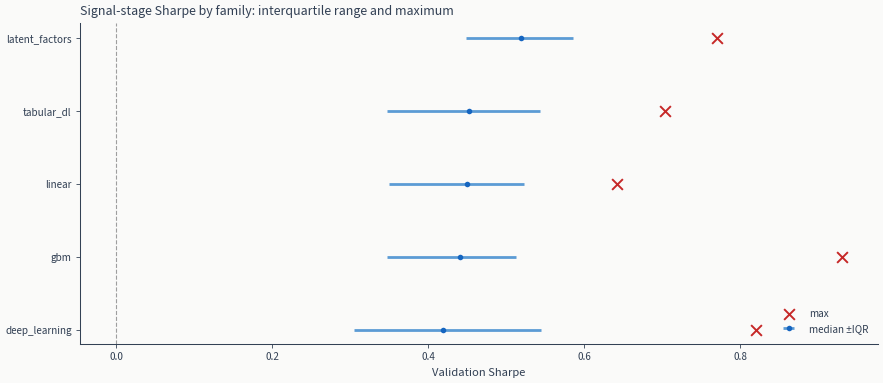

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    label="median ±IQR",
)
ax.scatter(maxima, y, marker="x", color="#C62828", s=60, label="max", zorder=5)
ax.axvline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
ax.set_title("Signal-stage Sharpe by family: interquartile range and maximum")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.show()

**The median and the maximum answer different questions, which is why both are drawn.** A
family's median says what a configuration drawn from it typically does; its maximum says what its
strongest one did, and the strongest is what a search returns. A family whose maximum stands far above
its own median is a family whose leader is mostly a draw from a wide distribution.

**Where the families sit relative to each other matters less than how much they overlap.** Read
the interquartile bars: where they cover each other, the ordering between those families is not
something the signal stage decided, and the selected configuration's family may hold that
position because of the stages that came after rather than because of the signal.

**The lineage waterfall below is where that is settled.** It tracks one prediction through
signal, allocation, cost and risk, so a leader that arrives in the lead late - lifted by portfolio
construction rather than by its ranking - is visible as a rising line rather than as a high
starting point. Neither shape is better; they are different claims about where the performance
came from.

In [11]:
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for rank-1 prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

Lineage stages present for rank-1 prediction:
  signal: hash=6748a35a25e4, Sharpe=0.930 [0.264, 1.885]
  allocation: hash=f8dd08891657, Sharpe=0.939 [0.247, 1.838]
  risk_overlay: hash=303a3d07b83e, Sharpe=1.317 [0.732, 1.939]
  cost_sensitivity: hash=ca4e0641a270, Sharpe=1.594 [1.026, 2.219]


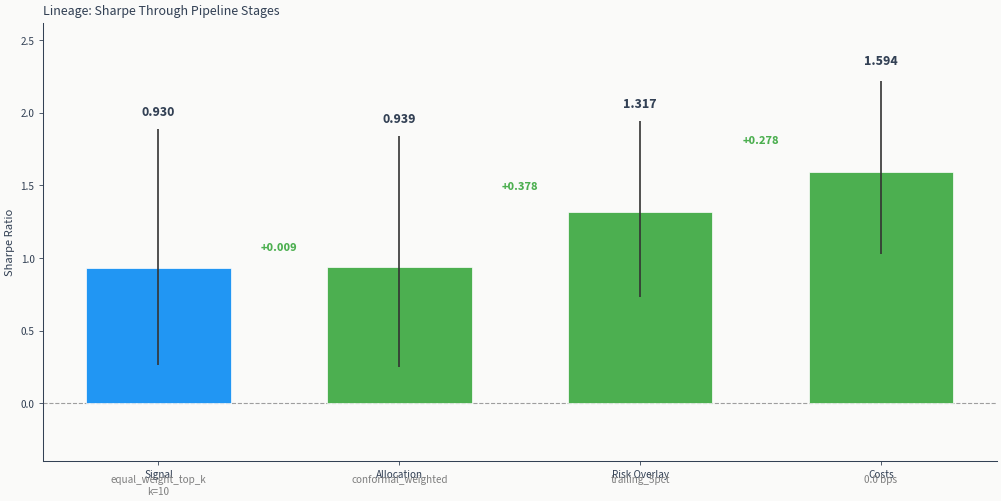

In [12]:
fig = plot_sharpe_waterfall(lineage, ci_lo=ci_lo, ci_hi=ci_hi)
fig.show()

In [13]:
# Stage-transition deltas via load_paired_metrics — never recompute paired
# metrics inline. ETFs is one of the few CSs whose rank-1 prediction has
# all four pipeline stages registered against it, so each transition has
# a populated paired row.
# The pairs are the consecutive stages this prediction actually has, taken in
# STAGE_SEQUENCE order, which is the order the backtests run: size positions,
# apply risk controls, then measure what realistic costs take off the winner.
present = [s for s in STAGE_SEQUENCE if lineage.get(s)]
for stage_name in STAGE_SEQUENCE:
    if lineage.get(stage_name) is None:
        print(f"Stage {stage_name}: not run for this prediction")
for prev_stage, stage_name in zip(present, present[1:]):
    kind = f"{prev_stage}_leader"
    stage_info = lineage[stage_name]
    # champion_lineage selects each stage independently, so two entries can be
    # siblings rather than parent and child. The producer writes a paired row
    # only where the later stage carries the earlier one's whole strategy
    # prefix; asking for one it declined to write is normal, and the reason is
    # worth naming rather than reporting as a missing row.
    if not descends_from(
        stage_info.get("_strategy", {}),
        lineage[prev_stage].get("_strategy", {}),
        prev_stage,
    ):
        print(
            f"Stage {stage_name}: not paired against {kind} - this run does not "
            f"descend from the {prev_stage} leader, so the two are siblings and "
            f"the difference between them is not a stage effect."
        )
        continue
    pair = load_paired_metrics(
        CASE_STUDY,
        challenger_hash=stage_info["backtest_hash"],
        benchmark_kind=kind,
    )
    if pair.is_empty():
        print(f"Stage {stage_name}: paired row missing for kind={kind}")
        continue
    r = pair.row(0, named=True)
    print(f"{stage_name} challenger vs {kind}:")
    print(
        f"  sharpe_diff = "
        f"{_fmt_ci(r['sharpe_diff'], r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}"
    )
    print(f"  p_value = {r['p_value']:.3f}")
    print(f"  prob_challenger_wins = {r['prob_challenger_wins']:.3f}")
    print(f"  CI status: {ci_status(r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}")
    moved = _changed(stage_info["backtest_hash"], r["benchmark_hash"])
    print(f"  axes that differ: {', '.join(moved) if moved else 'none'}")
    chal_axes, bench_axes = _axes(stage_info["backtest_hash"]), _axes(r["benchmark_hash"])
    if "cost model" in moved and _priced(bench_axes) and not _priced(chal_axes):
        # Read the other way round, which is the direction the comparison supports.
        print(
            f"  the challenger is the frictionless member of the cost grid and the benchmark is "
            f"priced, so what this measures is the price of friction: {r['sharpe_diff']:.3f} "
            f"Sharpe, not a gain the cost stage produced"
        )
    if len(moved) > 1:
        print(
            f"  {len(moved)} axes moved at once, so none of the difference is attributable to "
            f"{stage_name} specifically"
        )
    print()

Stage allocation: not paired against signal_leader - this run does not descend from the signal leader, so the two are siblings and the difference between them is not a stage effect.
risk_overlay challenger vs allocation_leader:
  sharpe_diff = 0.379 [-0.124, 0.863]
  p_value = 0.144
  prob_challenger_wins = 0.902
  CI status: straddles_zero
  axes that differ: risk overlay

cost_sensitivity challenger vs risk_overlay_leader:
  sharpe_diff = 0.278 [0.246, 0.312]
  p_value = 0.000
  prob_challenger_wins = 1.000
  CI status: excludes_zero_strong
  axes that differ: cost model
  the challenger is the frictionless member of the cost grid and the benchmark is priced, so what this measures is the price of friction: 0.278 Sharpe, not a gain the cost stage produced



Read the transitions printed above against the order the backtests run:
positions are sized, risk controls are applied to the sized strategy, and
costs are charged against the strategy that survives both. Each printed row
compares a stage against the leader of the stage before it, so a positive
`sharpe_diff` is what that one step added and nothing else.

Two readings need care. A confidence interval that straddles zero means the
step's contribution is not resolved at this sample - the point estimate still
says which way it leaned, and `prob_challenger_wins` says how often it led
across bootstrap draws, but neither is a rejection. And a transition reported
as siblings rather than a pair is not a gap in the evidence: the two stages
were selected independently and the later one does not carry the earlier
one's configuration, so their difference mixes the stage with everything else
that differs between them, and no paired row is written for it.

Allocation: best Sharpe by top_k:
shape: (3, 4)
┌───────┬────────────────────┬──────────┬──────────────┐
│ top_k ┆ allocator          ┆ sharpe   ┆ max_drawdown │
│ ---   ┆ ---                ┆ ---      ┆ ---          │
│ i64   ┆ str                ┆ f64      ┆ f64          │
╞═══════╪════════════════════╪══════════╪══════════════╡
│ 5     ┆ conformal_weighted ┆ 0.938865 ┆ -0.422683    │
│ 10    ┆ conformal_weighted ┆ 0.842383 ┆ -0.393553    │
│ 20    ┆ conformal_weighted ┆ 0.707152 ┆ -0.33892     │
└───────┴────────────────────┴──────────┴──────────────┘


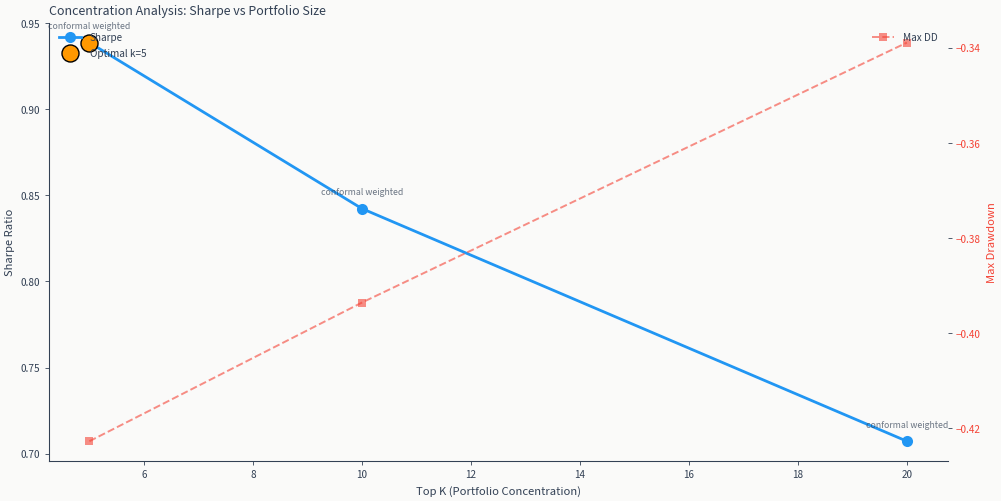

In [14]:
conc_df = explorer.concentration_curve(TOP_PHASH)
if not conc_df.is_empty():
    fig = plot_concentration_curve(conc_df)
    fig.show()
    best_per_k = conc_df.sort("sharpe", descending=True).group_by("top_k").first().sort("top_k")
    print("Allocation: best Sharpe by top_k:")
    print(best_per_k.select("top_k", "allocator", "sharpe", "max_drawdown"))
else:
    print("No concentration data - allocation stage absent for this prediction.")

**Concentration is the portfolio decision the ranking does not make.** Holding fewer funds uses
more of the signal's confidence and less of the universe's diversification; holding more does the
reverse. On a cross-asset universe that trade has a second edge, because the funds are drawn from
equities, bonds, commodities and currencies, and a tight selection can end up inside one of those
rather than across them.

The curve is read for where it flattens rather than for its maximum. A maximum picked off this
scan is a selection over the same validation window everything else was selected on, and the
concentration the lineage actually uses is the one the allocation stage registered.

## §3 What the strategy earned, with its uncertainty

One strategy, one validation window, every figure with the interval the block bootstrap gives it.
The block bootstrap rather than an independent one because daily strategy returns are serially
dependent, and resampling them independently would produce an interval far tighter than the data
support.

The equity overlay puts the strategy against the equal-weight ETF universe over the same dates.
That benchmark is the honest comparator for this case study: it holds the same instruments with
no model at all, so the gap between the two curves is what the ranking bought.

In [15]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": SELECTED_LABEL,
    "signal_method": lineage["signal"].get("signal_method"),
    "top_k": lineage["signal"].get("top_k"),
    "allocation": lineage.get("allocation", {}).get("allocator"),
    "cost_assumption": "no costs at signal stage; sensitivity in §5",
    "risk_overlay": lineage.get("risk_overlay", {}).get("risk_name"),
    "validation_window_periods": int(full["n_periods"]),
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full.get("avg_turnover"),
    "bootstrap_block_length": int(full["bootstrap_block_length"]),
    "bootstrap_n": int(full["bootstrap_n"]),
}
print("The selected configuration specification (signal stage, validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

# Audit: bootstrap_block_length resolves from the label horizon (21 trading
# days for fwd_ret_21d). Rebalance cadence in setup.yaml is monthly
# month-end (~21 bars) - the two encode the same autocorrelation scale.
_block = int(full["bootstrap_block_length"])
print(
    f"  audit: bootstrap_block_length={_block} days "
    f"(rebalance cadence={setup['decision']['cadence']} ≈ 21 bars)"
)

The selected configuration specification (signal stage, validation window):
  case_study: etfs
  family: gbm
  config_name: leaves_63_mse
  label: fwd_ret_5d
  signal_method: equal_weight_top_k
  top_k: 10
  allocation: conformal_weighted
  cost_assumption: no costs at signal stage; sensitivity in §5
  risk_overlay: trailing_5pct
  validation_window_periods: 2011
  num_trades: 1789
  avg_turnover: 0.07453433723499701
  bootstrap_block_length: 12
  bootstrap_n: 1000
  audit: bootstrap_block_length=12 days (rebalance cadence=monthly_month_end ≈ 21 bars)


In [16]:
sharpe_status = ci_status(full["sharpe_ci95_lo"], full["sharpe_ci95_hi"])
sortino_status = ci_status(full["sortino_ci95_lo"], full["sortino_ci95_hi"])
ann_status = ci_status(full["ann_return_ci95_lo"], full["ann_return_ci95_hi"])
mdd_status = ci_status(full["max_dd_ci95_lo"], full["max_dd_ci95_hi"])
calmar_status = ci_status(full["calmar_ci95_lo"], full["calmar_ci95_hi"])


def _hrow(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}


# The selection-adjusted columns join in from cohort_metrics and carry no per-row interval, so
# their CI cells read as unavailable rather than as a computed bound.
headline = pl.DataFrame(
    [
        _hrow(
            "Sharpe",
            _fmt(full["sharpe"]),
            _fmt(full["sharpe_ci95_lo"]),
            _fmt(full["sharpe_ci95_hi"]),
            sharpe_status,
        ),
        _hrow(
            "Sortino",
            _fmt(full["sortino"]),
            _fmt(full["sortino_ci95_lo"]),
            _fmt(full["sortino_ci95_hi"]),
            sortino_status,
        ),
        _hrow(
            "Annualized return",
            _fmt(full["cagr"]),
            _fmt(full["ann_return_ci95_lo"]),
            _fmt(full["ann_return_ci95_hi"]),
            ann_status,
        ),
        _hrow(
            "Max drawdown",
            _fmt(full["max_drawdown"]),
            _fmt(full["max_dd_ci95_lo"]),
            _fmt(full["max_dd_ci95_hi"]),
            mdd_status,
        ),
        _hrow(
            "Calmar",
            _fmt(full["calmar"]),
            _fmt(full["calmar_ci95_lo"]),
            _fmt(full["calmar_ci95_hi"]),
            calmar_status,
        ),
        {
            "metric": "PSR p-value (H0: SR≤0)",
            "point": _fmt(full["psr_pvalue"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": "DSR (selection-adjusted)",
            "point": _fmt(full["dsr"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": "Expected max Sharpe",
            "point": _fmt(full["expected_max_sharpe"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
        {
            "metric": "PBO",
            "point": _fmt(full["pbo"]),
            "ci95_lo": "-",
            "ci95_hi": "-",
            "status": "n/a",
        },
    ]
)
print("The selected configuration headline metrics with 95% CIs:")
print(headline)

The selected configuration headline metrics with 95% CIs:
shape: (9, 5)
┌──────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                   ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                      ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                      ┆ str     ┆ str     ┆ str     ┆ str                  │
╞══════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                   ┆ 1.3167  ┆ 0.7318  ┆ 1.9394  ┆ excludes_zero_strong │
│ Sortino                  ┆ 2.1969  ┆ 1.1394  ┆ 3.4308  ┆ excludes_zero_strong │
│ Annualized return        ┆ 0.2051  ┆ 0.1003  ┆ 0.3277  ┆ excludes_zero_strong │
│ Max drawdown             ┆ -0.1180 ┆ -0.2450 ┆ -0.1039 ┆ excludes_zero_strong │
│ Calmar                   ┆ 1.7377  ┆ 0.4897  ┆ 2.8199  ┆ excludes_zero_strong │
│ PSR p-value (H0: SR≤0)   ┆ 0.0000  ┆ -       ┆ -       ┆ n/a                  │
│ DSR (selection-adjusted)

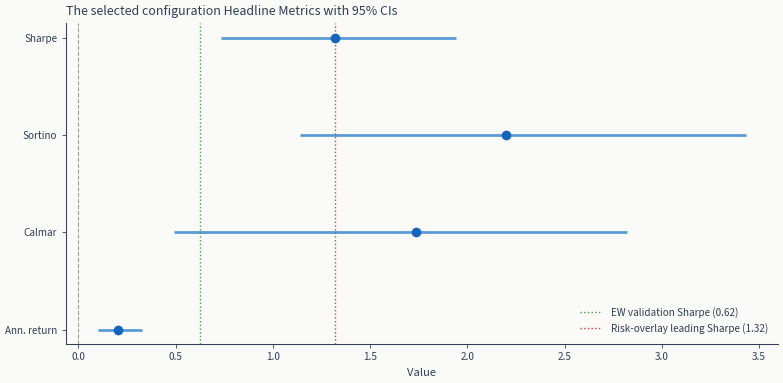

In [17]:
# Forest plot: rank-1 metrics with CI bars + reference lines
ew_val = load_benchmark_metrics(CASE_STUDY, SELECTED_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
    ("Ann. return", full["cagr"], full["ann_return_ci95_lo"], full["ann_return_ci95_hi"]),
]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color="#43A047",
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
risk_sharpe = lineage.get("risk_overlay", {}).get("sharpe")
if risk_sharpe is not None:
    ax.axvline(
        risk_sharpe,
        color="#E53935",
        linestyle=":",
        linewidth=1.0,
        label=f"Risk-overlay leading Sharpe ({risk_sharpe:.2f})",
    )
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Value")
ax.set_title("The selected configuration Headline Metrics with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

Validation overlay window: 2015-12-29 → 2023-12-21, n=2010


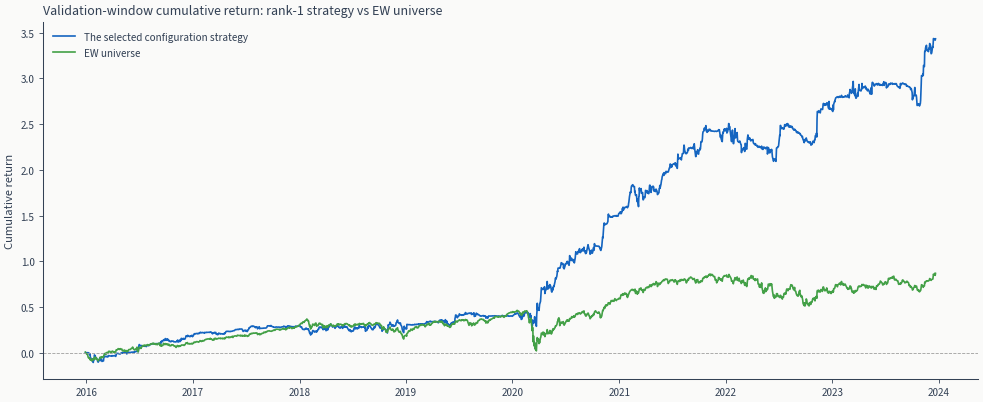

In [18]:
# Equity-curve overlay vs validation EW benchmark
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, SELECTED_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

cum_strat = np.cumprod(1 + aligned["strategy"].to_numpy()) - 1
cum_bench = np.cumprod(1 + aligned["benchmark"].to_numpy()) - 1
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(
    aligned["ts"],
    cum_strat,
    color="#1565C0",
    linewidth=1.2,
    label="The selected configuration strategy",
)
ax.plot(aligned["ts"], cum_bench, color="#43A047", linewidth=1.2, label="EW universe")
ax.axhline(0, color="#9E9E9E", linewidth=0.6, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_title("Validation-window cumulative return: rank-1 strategy vs EW universe")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
fig.show()

**The lower bound of the Sharpe interval is what the first gate reads**, and it answers a
narrower question than the point estimate: not how well the strategy did, but whether this window
is consistent with it having no edge at all. A point estimate cannot answer that; an interval can.

**The probabilistic Sharpe ratio is a second, parametric answer to the same question.** It
corrects for the skew and kurtosis a Sharpe ratio assumes away. Where the two disagree, the
bootstrap interval is the one that made fewer assumptions.

**The drawdown interval is not a test.** A drawdown is negative by construction, so an interval
excluding zero says nothing. What it bounds is the magnitude, and the width is what to size
against rather than the point.

**The selection-adjusted statistics are what price the search**, and they read as unavailable
rather than as favourable when `cohort_metrics` holds no row for this lineage. A deflated Sharpe
absent from a table is not a deflation of zero. Where they are absent the in-sample guard is the
probabilistic Sharpe alone and the decisive evidence moves to §6 - a weaker position, and worth
saying so.

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired
against the validation EW benchmark. The drawdown panel surfaces the
worst episode and recovery; rolling Sharpe and rolling beta locate
when the strategy decoupled from the universe. ETFs are among the
most liquid instruments in this book, so drawdowns reflect signal
decay or cross-asset rotation reversals rather than execution
slippage.

In [19]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=-0.0006016761116464486, max_drawdown=-0.11804124358502936, avg_drawdown=-0.032919990626072024, underwater_curve=shape: (2_010,)
Series: 'drawdown' [f64]
[
	0.0
	0.0
	0.0
	0.0
	0.0
	…
	-0.001154
	-0.002232
	-0.001777
	-0.003938
	-0.000602
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2022, 1, 11), valley_date=datetime.date(2022, 6, 22), recovery_date=datetime.date(2022, 11, 10), depth=np.float64(-0.11804124358502936), duration_days=111, recovery_days=99), DrawdownPeriod(peak_date=datetime.date(2020, 2, 19), valley_date=datetime.date(2020, 3, 23), recovery_date=datetime.date(2020, 3, 25), depth=np.float64(-0.11093722878056542), duration_days=23, recovery_days=2), DrawdownPeriod(peak_date=datetime.date(2016, 1, 8), valley_date=datetime.date(2016, 1, 25), recovery_date=datetime.date(2016, 5, 2), depth=np.float64(-0.10677310967278453), duration_days=10, recovery_days=68), DrawdownPeriod(peak_date=datetime.date

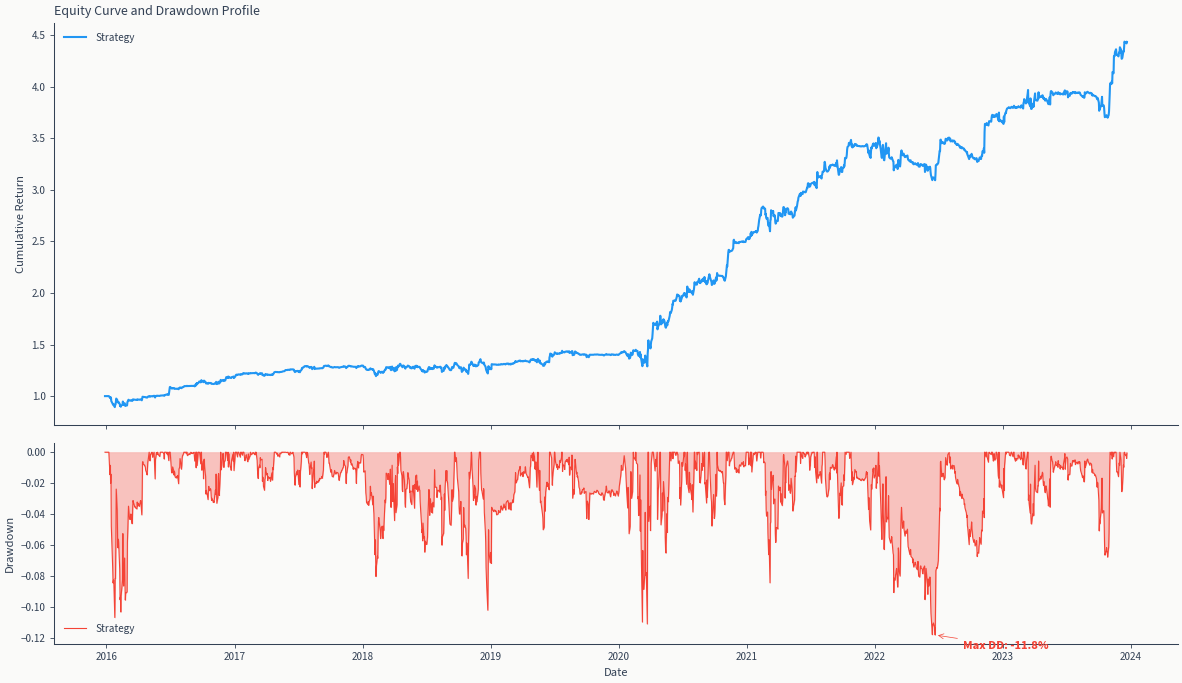

In [20]:
fig = plot_equity_drawdown(strat_returns_path)
fig.show()

In [21]:
# Rolling Sharpe + rolling beta (window 126 ~ 6 months)
roll = pa.compute_rolling_metrics(windows=[126], metrics=["sharpe", "beta"])
print("Rolling-window keys:")
print({k: type(v).__name__ for k, v in roll.items()} if isinstance(roll, dict) else roll)

# Tail risk straight from registry
tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (daily)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (daily)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)

Rolling-window keys:
RollingMetricsResult(windows=[126], dates=shape: (2_010,)
Series: 'date' [date]
[
	2015-12-29
	2015-12-30
	2015-12-31
	2016-01-04
	2016-01-05
	…
	2023-12-15
	2023-12-18
	2023-12-19
	2023-12-20
	2023-12-21
], sharpe={126: shape: (2_010,)
Series: 'sharpe_126d' [f64]
[
	null
	null
	null
	null
	null
	…
	1.994407
	1.979401
	1.980952
	1.972366
	1.968044
]}, volatility={}, returns={}, beta={126: shape: (2_010,)
Series: 'beta_126d' [f64]
[
	null
	null
	null
	null
	null
	…
	0.837024
	0.847193
	0.837743
	0.823015
	0.824333
]})

Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.1503  │
│ VaR 95% (daily)   ┆ -0.0126 │
│ CVaR 95% (daily)  ┆ -0.0200 │
│ Tail ratio        ┆ 1.278   │
│ Skewness          ┆ 1.237   │
│ Kurtosis          ┆ 11.186  │
└───────────────────┴─────────┘


In [22]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
if fold_df.height > 0:
    print(f"Per-fold breakdown ({fold_df.height} folds):")
    print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))
    print()
    print(f"Fold Sharpe range: [{fold_df['sharpe'].min():.3f}, {fold_df['sharpe'].max():.3f}]")
    print(f"Fold Sharpe std:   {fold_df['sharpe'].std():.3f}")
else:
    print(
        "Per-fold metrics not populated for this backtest_hash. "
        "ETFs rank-1 was bootstrapped against the consolidated validation "
        "window rather than expanding-window folds; the strategy headline "
        "uses the consolidated CI, and §6's val→ho paired test substitutes "
        "for an explicit per-fold stability check."
    )

Per-fold breakdown (8 folds):
shape: (8, 4)
┌─────────┬───────────┬──────────────┬────────┐
│ fold_id ┆ sharpe    ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---       ┆ ---          ┆ ---    │
│ i64     ┆ f64       ┆ f64          ┆ f64    │
╞═════════╪═══════════╪══════════════╪════════╡
│ 0       ┆ 1.661513  ┆ -0.067756    ┆ 247.0  │
│ 1       ┆ 0.493997  ┆ -0.118041    ┆ 252.0  │
│ 2       ┆ 2.361613  ┆ -0.084358    ┆ 252.0  │
│ 3       ┆ 2.388901  ┆ -0.110937    ┆ 252.0  │
│ 4       ┆ 1.091263  ┆ -0.050104    ┆ 252.0  │
│ 5       ┆ -0.007416 ┆ -0.102053    ┆ 252.0  │
│ 6       ┆ 1.406487  ┆ -0.024606    ┆ 252.0  │
│ 7       ┆ 1.255674  ┆ -0.106773    ┆ 252.0  │
└─────────┴───────────┴──────────────┴────────┘

Fold Sharpe range: [-0.007, 2.389]
Fold Sharpe std:   0.832


**Depth and duration are different risks and only one is in the Sharpe.** A strategy can recover
quickly from a deep fall or sit underwater for years after a shallow one, and the second is what
ends a mandate. The panel reports both.

**Kurtosis decides whether the interval above can be trusted.** Heavy tails mean the observed
Sharpe rests on fewer effective observations than the sample size suggests, and a risk overlay
clipping the left tail harder than the right shows up here as skew moving with the overlay rather
than with the signal.

**Rolling Sharpe and rolling beta locate when the strategy stopped tracking its universe.** A
cross-asset strategy that is long equities most of the time has a beta near one and no
diversifying behaviour to show for itself. Where beta falls is where the model rotated into bonds
or commodities, and whether that helped is in the rolling Sharpe over the same dates.

## §5 How much friction the strategy tolerates

ETFs are among the most liquid instruments in this book: the spread on the largest funds is a
fraction of a basis point, while sector, international and commodity funds cost several. The cost
stage walked a per-leg grid over the selected configuration; the curve below is how its Sharpe
responds, with bands marking the most-liquid end of the universe and the typical one.

The reading that matters is the distance between the declared cost and where the curve crosses
zero, not the Sharpe at any single level. [`17_costs`](17_costs.ipynb) computes that crossing
directly and reports it as a bound when the grid does not reach it.

In [23]:
with sqlite3.connect(str(_db)) as _con:
    cost_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            WHERE b.stage = 'cost_sensitivity'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=[
            "spec_json",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
        ],
        orient="row",
    )


def _cost_bps(spec_str: str) -> float:
    """Per-leg cost (bps) extracted from locked spec.

    Cost rates live under backtest_config.commission.rate +
    backtest_config.slippage.rate as decimal fractions; sum × 10_000
    is total per-leg cost in bps.
    """
    spec = json.loads(spec_str)
    bc = spec.get("backtest_config", {})
    comm = bc.get("commission", {}) or {}
    slip = bc.get("slippage", {}) or {}
    return float((comm.get("rate", 0) + slip.get("rate", 0)) * 10000)


cost_df = cost_df.with_columns(
    pl.col("spec_json").map_elements(_cost_bps, return_dtype=pl.Float64).alias("cost_bps")
)
cost_curve = (
    cost_df.group_by("cost_bps")
    .agg(
        sharpe_max=pl.col("sharpe").max(),
        sharpe_min=pl.col("sharpe").min(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_ci_lo=pl.col("sharpe_ci95_lo").min(),
        sharpe_ci_hi=pl.col("sharpe_ci95_hi").max(),
        n=pl.len(),
    )
    .sort("cost_bps")
)
print("Cost sensitivity curve (validation, all configs):")
print(cost_curve)

Cost sensitivity curve (validation, all configs):
shape: (11, 7)
┌──────────┬────────────┬────────────┬───────────────┬──────────────┬──────────────┬─────┐
│ cost_bps ┆ sharpe_max ┆ sharpe_min ┆ sharpe_median ┆ sharpe_ci_lo ┆ sharpe_ci_hi ┆ n   │
│ ---      ┆ ---        ┆ ---        ┆ ---           ┆ ---          ┆ ---          ┆ --- │
│ f64      ┆ f64        ┆ f64        ┆ f64           ┆ f64          ┆ f64          ┆ u32 │
╞══════════╪════════════╪════════════╪═══════════════╪══════════════╪══════════════╪═════╡
│ 0.0      ┆ 1.594283   ┆ 0.298531   ┆ 0.966528      ┆ -0.324327    ┆ 2.219303     ┆ 35  │
│ 1.0      ┆ 1.538633   ┆ 0.84222    ┆ 1.152405      ┆ 0.133393     ┆ 2.165568     ┆ 5   │
│ 2.0      ┆ 1.484544   ┆ 0.832383   ┆ 1.144624      ┆ 0.124699     ┆ 2.113643     ┆ 5   │
│ 3.0      ┆ 1.428772   ┆ 0.822016   ┆ 1.136927      ┆ 0.113437     ┆ 2.058074     ┆ 5   │
│ 5.0      ┆ 1.318795   ┆ 0.801513   ┆ 1.12084       ┆ 0.093295     ┆ 1.943348     ┆ 5   │
│ …        ┆ …          ┆

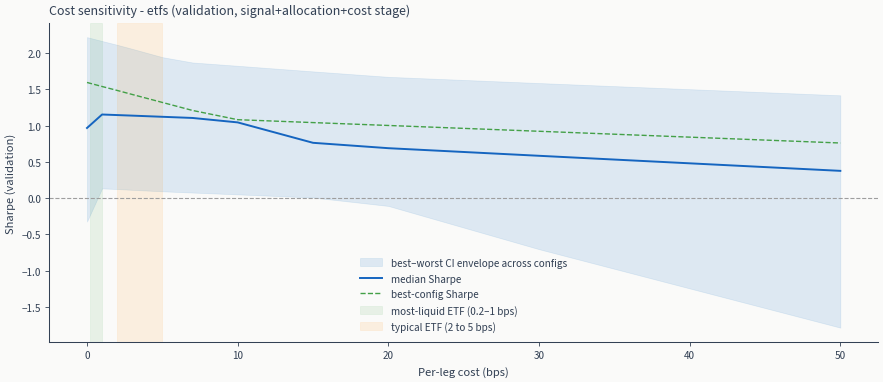

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = cost_curve["cost_bps"].to_numpy()
ax.fill_between(
    xs,
    cost_curve["sharpe_ci_lo"].to_numpy(),
    cost_curve["sharpe_ci_hi"].to_numpy(),
    alpha=0.18,
    color="#5B9BD5",
    label="best–worst CI envelope across configs",
)
ax.plot(
    xs,
    cost_curve["sharpe_median"].to_numpy(),
    color="#1565C0",
    linewidth=1.4,
    label="median Sharpe",
)
ax.plot(
    xs,
    cost_curve["sharpe_max"].to_numpy(),
    color="#43A047",
    linewidth=1.0,
    linestyle="--",
    label="best-config Sharpe",
)
ax.axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
# Realistic ETF friction:
# - Most-liquid ETF spread (SPY/QQQ/IWM): 0.2-1 bps round-trip
# - Typical ETF spread: 2-5 bps round-trip
ax.axvspan(0.2, 1.0, color="#43A047", alpha=0.10, label="most-liquid ETF (0.2–1 bps)")
ax.axvspan(2.0, 5.0, color="#FB8C00", alpha=0.10, label="typical ETF (2 to 5 bps)")
ax.set_xlabel("Per-leg cost (bps)")
ax.set_ylabel("Sharpe (validation)")
ax.set_title("Cost sensitivity - etfs (validation, signal+allocation+cost stage)")
ax.legend(loc="best", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

In [25]:
# Breakeven cost: where the best-config Sharpe lower bound crosses zero.
crossing_rows = cost_curve.filter(pl.col("sharpe_ci_lo") > 0)
if not crossing_rows.is_empty():
    breakeven = crossing_rows["cost_bps"].max()
    print(f"Sharpe CI lower bound stays > 0 up to: {breakeven:.0f} bps")
else:
    print("Sharpe CI lower bound never exceeds 0 across the cost grid.")

# Setup-encoded cost configuration
cost_config = setup.get("costs", {})
print()
print("Realistic ETF friction (per setup.yaml):")
for k, v in cost_config.items():
    print(f"  {k}: {v}")
print("See Chapter 18 for the transaction-cost framework.")

Sharpe CI lower bound stays > 0 up to: 15 bps

Realistic ETF friction (per setup.yaml):
  class: material
  model: per_share_plus_spread
  per_share: 0.0035
  minimum: 0.0
  asset_spreads: {'SPY': 0.005, 'QQQ': 0.005, 'IWM': 0.005, 'EFA': 0.005, 'EEM': 0.005, 'DIA': 0.005, 'VTI': 0.005, 'XLK': 0.01, 'XLF': 0.01, 'XLV': 0.01, 'XLE': 0.01, 'XLY': 0.01, 'XLI': 0.01, 'XLP': 0.01, 'XLU': 0.01, 'XLB': 0.01, 'XLRE': 0.01, 'XLC': 0.01}
  default_half_spread_usd: 0.02
  spread_convention: half_spread
  source: Industry-knowledge tiers; Yahoo daily OHLCV has no bid/ask.
See Chapter 18 for the transaction-cost framework.


**Read the dispersion across configurations against the slope of the cost curve.** Where the
spread between configurations at one cost level is wider than the effect of moving several
levels, friction is not what decides this strategy's fate and the choice of configuration is.
That is the ordinary situation for a monthly strategy, and it is a statement about the cadence
rather than about the model. [`17_costs`](17_costs.ipynb) computes the crossing directly.

## §6 The holdout, opened once

Everything above is measured on the window the strategy was selected on. This section is the only
out-of-sample evidence in the case study, and the holdout may be spent once: it is read here, and
nothing that follows may be used to choose anything.

Two paired tests. The first asks whether the edge held between the window that selected the
strategy and the window that did not. The second asks whether it beat the equal-weight universe
*inside* the holdout - the same instruments, the same dates, no model. Both come from
`backtest_paired_metrics`, never from subtracting one Sharpe from another.

The anchor is the holdout backtest that replays the selected configuration's **strategy**, not the
highest-Sharpe holdout backtest sharing its training hash. Matching on the strategy keeps the
anchor on the lineage that was actually selected, even where an experimental side-channel
allocator shares the holdout prediction set and posts a higher holdout Sharpe. The
`val_rank1_self` pair is written against the canonical lineage's holdout hash, so it is findable
only under that match.

When no such backtest exists the section reports which state the registry is in and computes
nothing further. The ordinary case is that the holdout has not been evaluated yet, which a
reader working the case study in order meets before it has, and that is a stage that has not
run rather than a failure of this one.

In [26]:
holdout_replay = resolve_holdout_self_backtest(CASE_STUDY, TOP_HASH)
HOLDOUT_AVAILABLE = holdout_replay.found
HO_HASH = holdout_replay.backtest_hash

print(f"Validation rank-1 hash: {TOP_HASH}")
if HOLDOUT_AVAILABLE:
    print(f"Holdout rank-1 hash:    {HO_HASH}")
else:
    print(f"Holdout closure unavailable: {holdout_replay.reason}")

val_full = full
ho_full = (
    load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
    if HOLDOUT_AVAILABLE
    else None
)

Validation rank-1 hash: 303a3d07b83e
Holdout rank-1 hash:    985f7e31081f


A missing paired row is reported as missing rather than filled with NaN. A NaN decay propagates
into the table below, into the section-9 gate, and into the assessment artifact, where it prints
as a dash that a reader cannot distinguish from a computed zero - and the gate would then be
evaluated on a comparison that was never made. Nothing here is computed from a substitute.

In [27]:
vh = None
if HOLDOUT_AVAILABLE:
    val_ho_pair = load_paired_metrics(
        CASE_STUDY, challenger_hash=HO_HASH, benchmark_kind="val_rank1_self"
    )
    if val_ho_pair.is_empty():
        print(
            "The holdout replay is registered but carries no val_rank1_self pair, so the "
            "validation-to-holdout decay cannot be computed. The populator writes that pair "
            "only when both series overlap enough to bootstrap."
        )
    else:
        vh = val_ho_pair.row(0, named=True)
VAL_HO_DECAY_AVAILABLE = vh is not None


def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f") if v is not None else "-",
        "holdout": _fmt(h, ".4f") if h is not None else "-",
        "diff (h-v)": _fmt(diff, ".4f") if diff is not None else "-",
        "diff CI95": (f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "-"),
        "p-value": _fmt(p, ".4f") if p is not None else "-",
    }


if not VAL_HO_DECAY_AVAILABLE:
    print("No validation-to-holdout decay to report.")
else:
    val_ho_table = pl.DataFrame(
        [
            _diff_row(
                "Sharpe",
                val_full["sharpe"],
                ho_full["sharpe"],
                vh["sharpe_diff"],
                vh["sharpe_diff_ci95_lo"],
                vh["sharpe_diff_ci95_hi"],
                vh["p_value"],
            ),
            _diff_row(
                "Annualized return",
                val_full["cagr"],
                ho_full["cagr"],
                vh["ret_diff"],
                vh["ret_diff_ci95_lo"],
                vh["ret_diff_ci95_hi"],
                None,
            ),
            _diff_row(
                "Max drawdown",
                val_full["max_drawdown"],
                ho_full["max_drawdown"],
                vh["max_dd_diff"],
                vh["max_dd_diff_ci95_lo"],
                vh["max_dd_diff_ci95_hi"],
                None,
            ),
            _diff_row(
                "Information ratio",
                None,
                None,
                vh["info_ratio"],
                vh["info_ratio_ci95_lo"],
                vh["info_ratio_ci95_hi"],
                None,
            ),
        ]
    )
    print("validation to holdout paired-bootstrap decay (rank-1 self):")
    print(val_ho_table)
    print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
    print(
        "CI status (Sharpe diff): "
        f"{ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}"
    )
    print()
    print(
        "The validation and holdout windows are disjoint by design, so the populator "
        "bootstraps each window separately over its whole length and takes the difference of "
        "independent draws. Nothing is truncated and no two draws are paired. Read the interval "
        "as a difference of two independently resampled Sharpes, not as a comparison over "
        "overlapping calendar time."
    )

validation to holdout paired-bootstrap decay (rank-1 self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h-v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ 1.3167     ┆ 1.1795  ┆ -0.1354    ┆ [-1.5365, 1.3347] ┆ 0.8635  │
│ Annualized return ┆ 0.2051     ┆ 0.1523  ┆ -0.0525    ┆ [-0.2674, 0.1901] ┆ -       │
│ Max drawdown      ┆ -0.1180    ┆ -0.1233 ┆ -0.0053    ┆ [-0.0557, 0.1856] ┆ -       │
│ Information ratio ┆ -          ┆ -       ┆ -          ┆ -                 ┆ -       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.430
CI status (Sharpe 

In [28]:
he = None
if HOLDOUT_AVAILABLE:
    ho_vs_ew = load_paired_metrics(
        CASE_STUDY,
        challenger_hash=HO_HASH,
        benchmark_kind="equal_weight_holdout_side_artifact",
    )
    if ho_vs_ew.is_empty():
        print(
            "The holdout replay is registered but carries no pair against the holdout-window "
            "equal-weight universe. The populator writes that pair only when the holdout "
            "backtest traded; a holdout with no trades has no return series to bootstrap."
        )
    else:
        he = ho_vs_ew.row(0, named=True)
HO_VS_EW_AVAILABLE = he is not None

if not HO_VS_EW_AVAILABLE:
    print("No holdout strategy-versus-benchmark comparison to report.")
else:
    ew_ho = load_benchmark_metrics(CASE_STUDY, SELECTED_LABEL, period="holdout")
    print("Holdout strategy against the holdout-window equal-weight universe:")
    print(f"  strategy Sharpe:  {ho_full['sharpe']:.3f}")
    print(f"  EW Sharpe:        {ew_ho['sharpe']:.3f}")
    print(
        "  diff Sharpe: "
        f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
    )
    print(f"  p_value:                {he['p_value']:.4f}")
    print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
    print(
        "  info_ratio (strategy vs EW): "
        f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
    )
    print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy against the holdout-window equal-weight universe:
  strategy Sharpe:  1.179
  EW Sharpe:        1.358
  diff Sharpe: -0.240 [-1.533, 0.792]
  p_value:                0.6930
  prob_challenger_wins:   0.312
  info_ratio (strategy vs EW): -0.085 [-1.507, 1.166]
  CI status: straddles_zero


**Two paired tests, and they answer different questions.** The first asks whether the strategy's
edge held between the window it was selected on and the window it was not: a large negative
difference says the selection did not generalize. The second asks whether it beat the naive
alternative *within* the holdout: the equal-weight universe, over the same dates, with no model
at all. A strategy can lose the first and win the second, or the reverse, and each is worth
knowing on its own.

**Both come from `backtest_paired_metrics` rather than from subtracting one Sharpe from
another.** A difference of point estimates has no interval, so it cannot say whether the gap is
larger than the noise. The paired bootstrap resamples the two return series together and gives
the difference its own confidence interval, which is the quantity the section-9 gate reads.

**The windows do not overlap in calendar time**, so there is nothing to pair. Each window is
bootstrapped separately over its whole length and the difference is formed from independent
draws, which is why the information ratio is null here: an information ratio needs a difference
*series*, and disjoint windows produce no such series. An interval read as though the two were
contemporaneous, or as though draws were matched to each other, would be read as something
stronger than it is.

**The holdout is short.** Whatever the point estimates, an interval computed over a window this
size is wide, and a decay that is not statistically resolved is the expected outcome rather than
a surprising one. What the point estimate says and what the interval excludes are two separate
readings, and the honest report gives both.

## §7 Benchmark-aware diagnostics

The canonical benchmark is the equal-weight ETF universe. Layer 1
reports the universal alpha/beta/IR profile via `PortfolioAnalysis`;
Layer 2 adds an FF5+MOM factor attribution with placebo-portfolio
control. ETFs span equities, bonds, commodities, and currencies, so
FF5+MOM (designed for individual US equities) captures only the
equity component - expect a modest R² rather than a strategy-defining
decomposition. The placebo benchmark separates universe-driven from
selection-driven factor exposure.

In [29]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬────────┐
│ metric             ┆ value  │
│ ---                ┆ ---    │
│ str                ┆ str    │
╞════════════════════╪════════╡
│ alpha (annualized) ┆ 0.1393 │
│ beta               ┆ 0.662  │
│ information ratio  ┆ 0.8660 │
│ tracking error     ┆ -      │
│ up capture         ┆ 0.3158 │
│ down capture       ┆ 7.5199 │
└────────────────────┴────────┘


In [30]:
# Placebo regression: residual α and HAC t-stat from regressing on EW alone.
import statsmodels.api as sm

X = sm.add_constant(bench_arr)
ols = sm.OLS(strat_arr, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_daily = ols.params[0]
alpha_t = ols.tvalues[0]
alpha_p = ols.pvalues[0]
beta = ols.params[1]
beta_t = ols.tvalues[1]
print()
print("Placebo regression vs EW universe (HAC, maxlags=5):")
print(f"  α (daily) = {alpha_daily:.6f}, α (annualized) = {alpha_daily * PERIODS_PER_YEAR:.4f}")
print(f"  α t-stat = {alpha_t:.3f}, p = {alpha_p:.3f}")
print(f"  β        = {beta:.3f}, β t-stat = {beta_t:.3f}")
print(f"  CI status (α): {'excludes_zero_strong' if alpha_p < 0.05 else 'straddles_zero'}")


Placebo regression vs EW universe (HAC, maxlags=5):
  α (daily) = 0.000553, α (annualized) = 0.1393
  α t-stat = 3.277, p = 0.001
  β        = 0.662, β t-stat = 7.625
  CI status (α): excludes_zero_strong


**Layer 2 - FF5+MOM factor attribution (HAC, 5 lags):**

In [31]:
strat_returns_pd = pd.Series(
    strat_arr,
    index=pd.to_datetime([str(t) for t in ts_arr]),
    name="strategy",
)
_start = str(strat_returns_pd.index.min().date())
_end = str(strat_returns_pd.index.max().date())
print(f"Factor attribution period: {_start} → {_end}, n={len(strat_returns_pd)}")

_factors = load_factor_data(start=_start, end=_end)
_reg = run_factor_regression(
    strat_returns_pd, _factors, model="ff5_mom", hac_lags=5, dollar_neutral=False
)

print(f"""
=== FF5+MOM Factor Attribution (HAC) ===
Observations:     {_reg["n_obs"]}
Strategy Sharpe:  {_reg["strategy_sharpe"]:+.2f}
Residual Sharpe:  {_reg["residual_sharpe"]:+.2f}
R^2:              {_reg["r_squared"]:.3f}
Alpha (ann.):     {_reg["alpha_annualized"]:+.1%} (t={_reg["alpha_t_stat"]:.2f}, p={_reg["alpha_p_value"]:.3f})
""")

print("Factor Betas:")
for factor, beta_f in _reg["betas"].items():
    t = _reg["t_stats"][factor]
    sig = "*" if _reg["p_values"][factor] < 0.05 else ""
    print(f"  {factor:8s}: {beta_f:+.4f}  (t={t:+.2f}){sig}")

Factor attribution period: 2015-12-29 → 2023-12-21, n=2010

=== FF5+MOM Factor Attribution (HAC) ===
Observations:     2010
Strategy Sharpe:  +1.22
Residual Sharpe:  +1.11
R^2:              0.370
Alpha (ann.):     +13.3% (t=3.12, p=0.002)

Factor Betas:
  Mkt-RF  : +0.4479  (t=+7.26)*
  SMB     : +0.0890  (t=+1.87)
  HML     : +0.0957  (t=+1.99)*
  RMW     : -0.0970  (t=-2.13)*
  CMA     : -0.0079  (t=-0.14)
  MOM     : -0.0134  (t=-0.34)


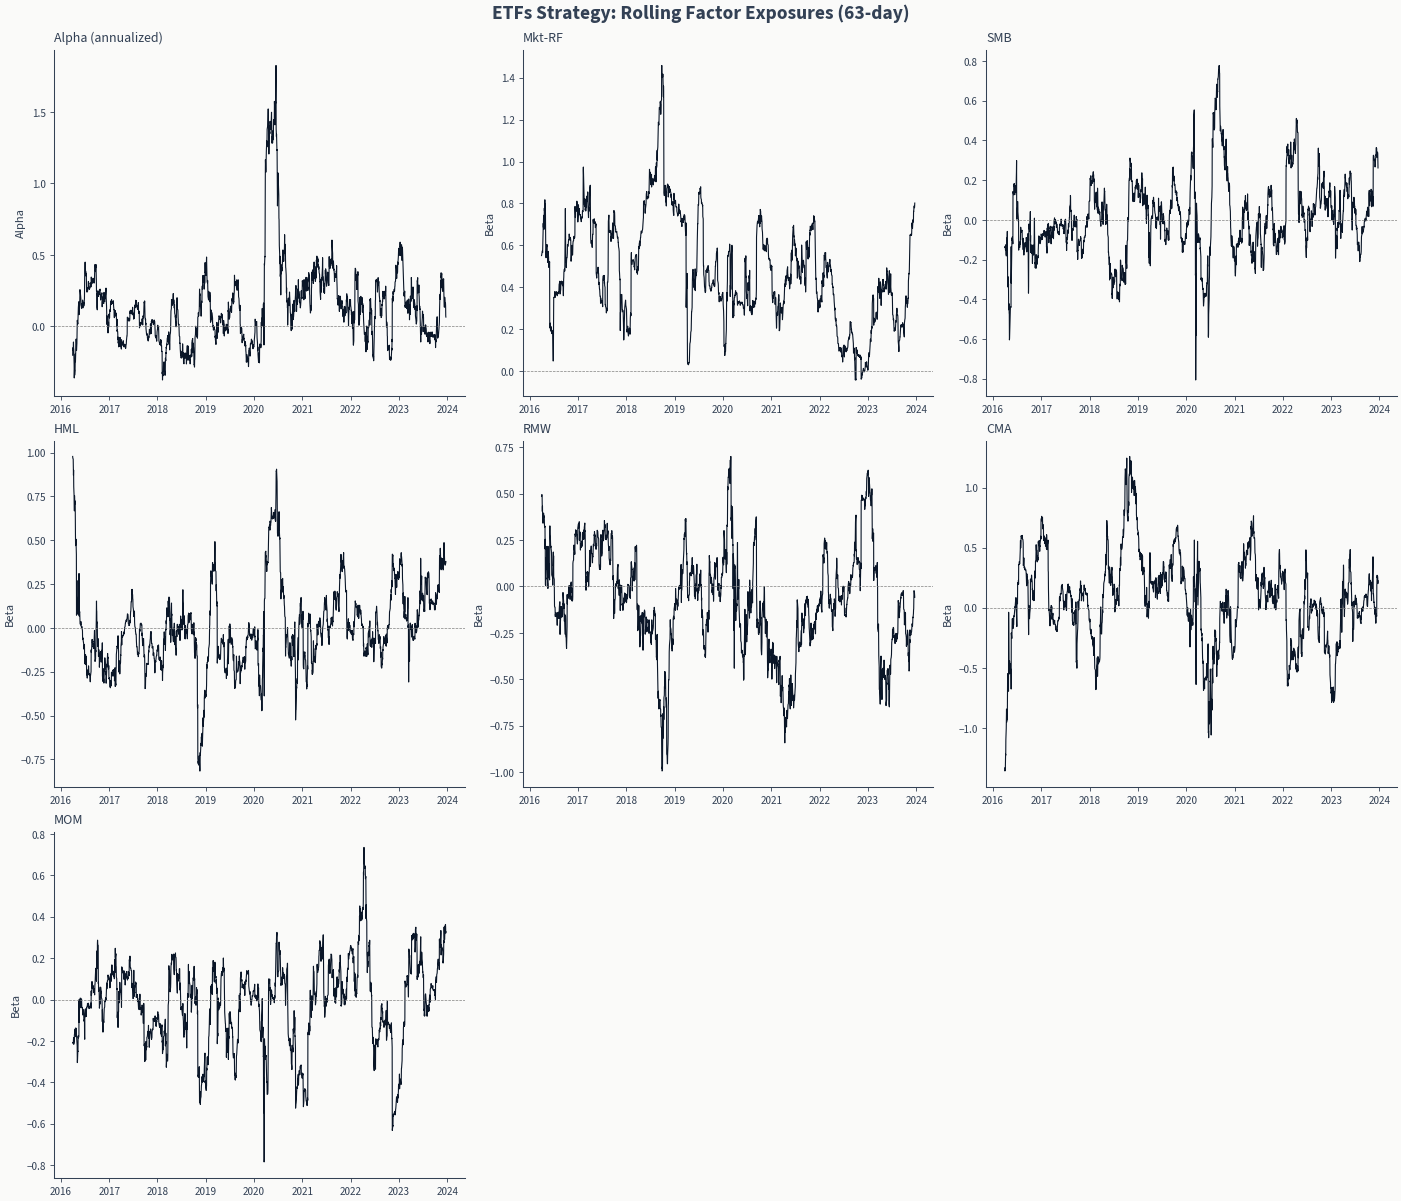

In [32]:
# Rolling factor exposures (63-day window ~ 3 months)
_rolling = compute_rolling_exposures(
    strat_returns_pd, _factors, model="ff5_mom", window=63, dollar_neutral=False
)
fig_roll = plot_rolling_exposures(
    _rolling, title="ETFs Strategy: Rolling Factor Exposures (63-day)"
)
fig_roll.show()

**Placebo benchmark (random ETF portfolios):**

In [33]:
from data import load_etfs as _load_etfs

_etf_data = _load_etfs()
_etf_daily = (
    _etf_data.sort("symbol", "timestamp")
    .with_columns(ret=pl.col("close").pct_change().over("symbol"))
    .drop_nulls("ret")
    .with_columns(date=pl.col("timestamp").dt.date())
    .group_by("symbol", "date")
    .agg(daily_ret=pl.col("ret").last())
    .sort("symbol", "date")
)
_etf_wide = (
    _etf_daily.pivot(on="symbol", index="date", values="daily_ret").to_pandas().set_index("date")
)
_etf_wide.index = pd.to_datetime(_etf_wide.index)

_placebo = run_placebo_benchmark(
    _etf_wide,
    _factors,
    n_sims=500,
    top_k=10,
    model="ff5_mom",
    dollar_neutral=False,
    seed=42,
)

if _placebo["n_sims"] > 0:
    print(f"""
=== Placebo Benchmark ({_placebo["n_sims"]} random long-only top-10 portfolios) ===
Random Mkt-RF beta: {_placebo["Mkt-RF_mean"]:+.3f} ± {_placebo["Mkt-RF_std"]:.3f}  [90% CI: {_placebo["Mkt-RF_p5"]:+.3f}, {_placebo["Mkt-RF_p95"]:+.3f}]
Random SMB beta:    {_placebo["SMB_mean"]:+.3f} ± {_placebo["SMB_std"]:.3f}
Random HML beta:    {_placebo["HML_mean"]:+.3f} ± {_placebo["HML_std"]:.3f}
Random alpha (ann): {_placebo["alpha_ann_mean"]:+.1%} ± {_placebo["alpha_ann_std"]:.1%}
Random R-squared:   {_placebo["r_squared_mean"]:.3f}
""")
    for factor in ("Mkt-RF", "SMB", "HML"):
        strat_beta = _reg["betas"].get(factor, 0)
        p5 = _placebo[f"{factor}_p5"]
        p95 = _placebo[f"{factor}_p95"]
        inside = "within" if p5 <= strat_beta <= p95 else "OUTSIDE"
        print(
            f"  Strategy {factor}: {strat_beta:+.3f} -- "
            f"{inside} random 90% CI [{p5:+.3f}, {p95:+.3f}]"
        )


=== Placebo Benchmark (500 random long-only top-10 portfolios) ===
Random Mkt-RF beta: +0.717 ± 0.113  [90% CI: +0.511, +0.885]
Random SMB beta:    +0.067 ± 0.074
Random HML beta:    +0.086 ± 0.086
Random alpha (ann): -0.0% ± 1.1%
Random R-squared:   0.855

  Strategy Mkt-RF: +0.448 -- OUTSIDE random 90% CI [+0.511, +0.885]
  Strategy SMB: +0.089 -- within random 90% CI [-0.036, +0.213]
  Strategy HML: +0.096 -- within random 90% CI [-0.039, +0.248]


In [34]:
# Block bootstrap CI on alpha and factor loadings
_boot = compute_bootstrap_ci(
    strat_returns_pd,
    _factors,
    model="ff5_mom",
    n_boot=1000,
    block_size=20,
    dollar_neutral=False,
    seed=42,
)
if _boot.get("n_boot", 0) > 0:
    print(
        f"=== Bootstrap CIs (n={_boot['n_boot']}, block=20 days) ===\n"
        f"Alpha (ann.) 95% CI: [{_boot['alpha_ann_lo']:+.1%}, {_boot['alpha_ann_hi']:+.1%}]"
    )
    for factor in _reg["factor_columns"]:
        key_lo = f"{factor}_lo"
        key_hi = f"{factor}_hi"
        if key_lo in _boot:
            print(f"  {factor:8s}: [{_boot[key_lo]:+.4f}, {_boot[key_hi]:+.4f}]")

=== Bootstrap CIs (n=1000, block=20 days) ===
Alpha (ann.) 95% CI: [+4.9%, +22.8%]
  Mkt-RF  : [+0.3719, +0.5389]
  SMB     : [-0.0049, +0.1778]
  HML     : [+0.0091, +0.1863]
  RMW     : [-0.2005, -0.0085]
  CMA     : [-0.1255, +0.1153]
  MOM     : [-0.0822, +0.0634]


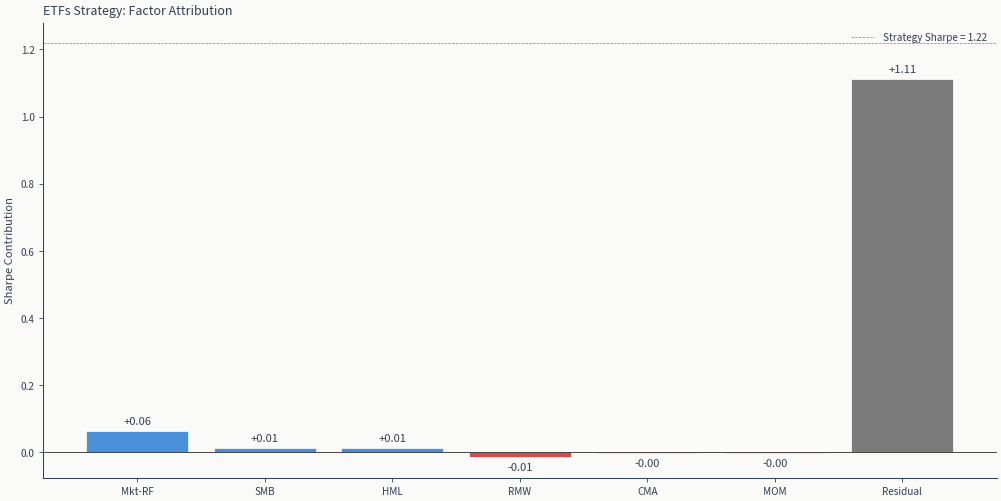

In [35]:
fig_attr = plot_attribution_waterfall(_reg, title="ETFs Strategy: Factor Attribution")
fig_attr.show()

Layer-1 placebo-regression alpha and Layer-2 FF5+MOM attribution
tell consistent stories. The cross-asset universe limits R² - bond,
commodity, and currency ETFs contribute returns largely orthogonal
to equity factors - so the residual Sharpe is a meaningful fraction
of the headline Sharpe, but the absolute alpha CI is wide enough
that "selection adds value over factor replication" cannot be
strongly resolved on the validation window alone. The placebo
benchmark confirms that random ETF portfolios show similarly modest
factor R² - the strategy's factor profile is partially
universe-driven rather than wholly selection-driven. AQR cross-asset
factors (TSMOM, value-everywhere, term-structure carry) would
provide a more complete attribution; that is a Ch20 cross-asset
extension rather than a per-CS deepening.

## §8 Strategy tear sheet

The diagnostic library renders the selected configuration's full tear sheet
directly from the on-disk artifacts; we wire the validation-window
equal-weight ETF universe in as the benchmark series. The tear sheet
HTML is written under `OUTPUT_DIR` and is gitignored - readers
regenerate it locally.

The artifacts are written by the stages above, not by this notebook, so the presence check
below is about ordering rather than about a healthy repository. Running 18 against a registry
where [`14_backtest`](14_backtest.ipynb) through
[`16_risk_management`](16_risk_management.ipynb) have not run leaves `TOP_HASH` naming a
directory that holds no `trades.parquet`, and the tear sheet fails on a missing file. Nothing
is broken and nothing needs repairing: run the backtest stages first.

In [36]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = (CASE_DIR / "run_log" / "backtest" / HO_HASH) if HOLDOUT_AVAILABLE else None
print(f"Validation backtest_dir: {backtest_dir}")
print(f"  trades.parquet present: {(backtest_dir / 'trades.parquet').exists()}")
if ho_dir is None:
    print("Holdout backtest_dir:    none, the holdout replay is not registered")
else:
    print(f"Holdout backtest_dir:    {ho_dir}")
    print(f"  trades.parquet present: {(ho_dir / 'trades.parquet').exists()}")

# generate_tearsheet_from_run_artifacts wants a 1-D benchmark series,
# not a multi-column DataFrame.
bench_series = aligned["benchmark"].to_numpy()

meta = BacktestReportMetadata(
    title="ETFs - The selected configuration Lineage",
    strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} - {SELECTED_LABEL}",
    universe=f"{setup['universe'].get('size', 100)} ETFs across categories",
    benchmark_name="ETF equal-weight universe (validation window)",
    evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
    calendar=setup.get("evaluation", {}).get("calendar", "NYSE"),
)

tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
html = generate_tearsheet_from_run_artifacts(
    backtest_dir,
    template="risk_manager",
    benchmark=bench_series,
    benchmark_name="EW universe (validation)",
    calendar=setup.get("evaluation", {}).get("calendar", "NYSE"),
    report_metadata=meta,
    output_path=str(tear_path),
)
print(f"Tear sheet written to: {tear_path}")
print(f"HTML size: {len(html):,} bytes")

Validation backtest_dir: ~/ml4t/public-etfs-nlinear/case_studies/etfs/run_log/backtest/303a3d07b83e
  trades.parquet present: True
Holdout backtest_dir:    ~/ml4t/public-etfs-nlinear/case_studies/etfs/run_log/backtest/985f7e31081f
  trades.parquet present: True


Tear sheet written to: ~/ml4t/public-etfs-nlinear/case_studies/ch20_etfs/etfs_tearsheet.html
HTML size: 1,140,930 bytes


## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside the ETF case study - cross-case-study
comparison is Ch20's lane.

In [37]:
op_profile = compute_operating_profile(lineage, setup)
# ETFs setup uses `decision.cadence` rather than evaluation_protocol.
op_profile = op_profile.with_columns(
    pl.when(pl.col("property") == "Trading cadence")
    .then(pl.lit(setup["decision"]["cadence"]))
    .otherwise(pl.col("value"))
    .alias("value")
)
print("Operating profile (etfs, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt(getattr(metrics, 'information_ratio', None))}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (etfs, validation window):
shape: (5, 2)
┌─────────────────────────────────┬────────────────────┐
│ property                        ┆ value              │
│ ---                             ┆ ---                │
│ str                             ┆ str                │
╞═════════════════════════════════╪════════════════════╡
│ Trading cadence                 ┆ monthly_month_end  │
│ Portfolio concentration (top_k… ┆ 5                  │
│ Allocator                       ┆ conformal weighted │
│ Cost assumption                 ┆ -                  │
│ Worst drawdown                  ┆ -42.3%             │
└─────────────────────────────────┴────────────────────┘

Sharpe: 1.317 [0.732, 1.939]
Info ratio (vs EW val): 0.8660
Max drawdown: -0.118


In [38]:
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
# The gate reads the holdout comparison, so without one there is no gate to evaluate. Reporting
# it as "not evaluated" is the answer; computing it from an absent difference would publish a
# pass or a fail that rests on nothing, which is worse than reporting neither.
if HO_VS_EW_AVAILABLE:
    gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
    gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(
        gate2_ci_status, he["sharpe_diff"]
    )
else:
    # `no_data` is the existing status for a gate with nothing to read, and
    # `gate_passes` already maps it to null in the assessment artifact. Inventing a
    # fourth state would put a string through `fmt_gate` that it has no label for.
    gate2_ci_status = None
    gate2_status = "no_data"
gate2_evidence = (
    "Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
    if HO_VS_EW_AVAILABLE
    else "the holdout has not been evaluated, so this gate has no comparison to read"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [PASS] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = 0.732 (≥ 0 (passes))
  [PASS] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = -0.240 [-1.533, 0.792] (straddles_zero)


**What this analysis does not say.**

**The validation window is one regime and the holdout is another.** A decade of US equity
strength under falling rates is not a sample of market conditions; it is one condition observed
for a long time. A holdout of a year or two in a different regime cannot separate a strategy that
stopped working from a strategy that works in conditions the holdout did not contain, and the
width of the decay interval is that ambiguity made visible rather than a defect in the test.

**The point estimates and the intervals can point in different directions, and both are true.**
A decay whose interval spans zero is not resolved; a decay whose point estimate is large is
still the most likely value. Reporting only the interval reads as reassurance and reporting only the
point reads as a conclusion. §6 prints both for that reason.

**Where the selection-adjusted statistics are absent, the in-sample guard is weaker than it
looks.** The probabilistic Sharpe corrects for the shape of one return distribution; it does not
correct for how many configurations were tried before this one was chosen. Only the deflated
Sharpe and the probability of backtest overfitting do that, and where `cohort_metrics` holds no
row for this lineage neither is available.

**Capacity is not modelled anywhere in this case study.** The strategy holds a fifth of the
universe at monthly frequency at the declared initial cash, and nothing here charges market
impact. Production sizing on the less liquid bond and commodity funds would face costs no curve
in §5 contains.

**What this case study contributes to the cross-case-study view.** It is the long-only,
cross-asset, monthly-cadence datapoint: a universe whose members are themselves diversified
portfolios, rebalanced twelve times a year rather than daily. Chapter 20 reads two things from
the assessment artifact written below - the selected configuration's Sharpe with its interval,
and the
holdout closure - and the second is recorded as absent rather than as null fields when the
holdout has not been evaluated, so a cross-case-study panel cannot average a stage that has not
run into one that has.

In [39]:
search_ctx = ctx
assessment = {
    "case_study": CASE_STUDY,
    "primary_label": PRIMARY_LABEL,
    "spine_version": "v1",
    "rank1": {
        "family": RANK1_FAMILY,
        "config_name": RANK1_CONFIG,
        "label": SELECTED_LABEL,
        "prediction_hash": TOP_PHASH,
        "validation_backtest_hash": TOP_HASH,
        "holdout_backtest_hash": HO_HASH,  # None until the holdout has been evaluated
    },
    "headline_performance": {
        "sharpe": {
            "point": val_full["sharpe"],
            "ci95_lo": val_full["sharpe_ci95_lo"],
            "ci95_hi": val_full["sharpe_ci95_hi"],
            "ci_status": sharpe_status,
        },
        "sortino": {
            "point": val_full["sortino"],
            "ci95_lo": val_full["sortino_ci95_lo"],
            "ci95_hi": val_full["sortino_ci95_hi"],
        },
        "ann_return": {
            "point": val_full["cagr"],
            "ci95_lo": val_full["ann_return_ci95_lo"],
            "ci95_hi": val_full["ann_return_ci95_hi"],
        },
        "max_drawdown": {
            "point": val_full["max_drawdown"],
            "ci95_lo": val_full["max_dd_ci95_lo"],
            "ci95_hi": val_full["max_dd_ci95_hi"],
        },
        "psr_pvalue": val_full["psr_pvalue"],
        "bootstrap_block_length": int(val_full["bootstrap_block_length"]),
        "bootstrap_n": int(val_full["bootstrap_n"]),
    },
    "selection_bias": {
        "k_variants": (
            int(val_full["k_variants"]) if val_full.get("k_variants") is not None else None
        ),
        "dsr": val_full.get("dsr"),
        "dsr_pvalue": val_full.get("dsr_pvalue"),
        "expected_max_sharpe": val_full.get("expected_max_sharpe"),
        "min_trl_periods": val_full.get("min_trl_periods"),
        "pbo": val_full.get("pbo"),
        "pbo_n_folds": (
            int(val_full["pbo_n_folds"]) if val_full.get("pbo_n_folds") is not None else None
        ),
        "pbo_n_combinations": (
            int(val_full["pbo_n_combinations"])
            if val_full.get("pbo_n_combinations") is not None
            else None
        ),
        "selection_adjustment_unavailable": val_full.get("dsr") is None,
    },
    "benchmark_relative": {
        "benchmark_name": "equal_weight_universe",
        "benchmark_validation_sharpe": ew_val["sharpe"],
        "benchmark_holdout_sharpe": ew_ho["sharpe"] if HO_VS_EW_AVAILABLE else None,
        "alpha_annualized_placebo": float(alpha_daily * PERIODS_PER_YEAR),
        "alpha_t_hac": float(alpha_t),
        "beta_to_ew": float(beta),
        "factor_attribution": format_attribution_summary(_reg, _boot),
    },
    # The artifact records the holdout closure only when there is one. A block of nulls under
    # this key would be read downstream as a measured absence of decay rather than as a stage
    # that has not run, and Chapter 20 aggregates across case studies on exactly these fields.
    "holdout_decay": None
    if not VAL_HO_DECAY_AVAILABLE
    else {
        "val_hash": TOP_HASH,
        "holdout_hash": HO_HASH,
        "sharpe_diff": vh["sharpe_diff"],
        "sharpe_diff_ci95_lo": vh["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci95_hi": vh["sharpe_diff_ci95_hi"],
        "sharpe_diff_p_value": vh["p_value"],
        "info_ratio": vh["info_ratio"],
        "decay_classification": ci_status(vh["sharpe_diff_ci95_lo"], vh["sharpe_diff_ci95_hi"]),
        "vs_ew_holdout": None
        if not HO_VS_EW_AVAILABLE
        else {
            "sharpe_diff": he["sharpe_diff"],
            "sharpe_diff_ci95_lo": he["sharpe_diff_ci95_lo"],
            "sharpe_diff_ci95_hi": he["sharpe_diff_ci95_hi"],
            "p_value": he["p_value"],
            "ci_status": ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"]),
        },
    },
    "search_context": {
        "total_signal_backtests": int(search_ctx["total"]),
        "median_sharpe": search_ctx["median_sharpe"],
        "p90_sharpe": search_ctx["p90_sharpe"],
        "pct_positive": search_ctx["pct_positive"],
    },
    "kill_gates": {
        "validation_sharpe_ci_lower_bound_geq_zero": gate_passes(gate1_status),
        "holdout_vs_ew_ci_does_not_exclude_zero_negatively": gate_passes(gate2_status),
    },
    "ch20_handoff": {
        "contributes_to": [
            "Ch20 nb01 - cross-CS leading Sharpe and holdout-decay aggregation",
            "Ch20 nb05 - strategy-vs-universe holdout panel (long-only multi-asset datapoint)",
        ],
        "asset_class_label": "etfs_cross_asset",
        "rebalance_cadence": setup["decision"]["cadence"],
    },
}
assessment_path = write_strategy_assessment(CASE_STUDY, assessment)
print(f"strategy_assessment.json written to: {assessment_path}")

strategy_assessment.json written to: ~/ml4t/public-etfs-nlinear/case_studies/etfs/results/strategy_assessment.json
